# Predicting the Century of Creation of an Artwork Using Museum Metadata

This notebook builds a machine learning classifier that predicts the **century of creation** of an artwork using museum metadata from:

- The Art Institute of Chicago API
-The MET


The target variable is the artwork's **century**, created from the museum-provided date fields. The model uses metadata such as artist, culture, medium, dimensions, classification, department, object name, and title.

In [ ]:
import requests
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

##Helper Functions

These functions clean date fields, extract a year, convert the year into a century label.

In [ ]:
def extract_year_from_text(value):

    #if date is empty return nothing
    if pd.isna(value):
        return np.nan

    #normalizw data, and lowercase
    text = str(value).lower()
    text = text.replace("ca.", "").replace("c.", "").replace("circa", "").replace("\u2013", "-").replace("\u2014", "-")

    # Determine early/mid/late qualifier offset within a century
    #early, late, mid, to a general year
    if "early" in text:
        qualifier = 15
    elif "mid" in text or "middle" in text:
        qualifier = 50
    elif "late" in text:
        qualifier = 85
    else:
        qualifier = 50

    #the math to find the year
    #match ordinal century strings: "18th century", "2nd century", etc.
    century_match = re.search(r"(\d{1,2})(?:st|nd|rd|th)\s*century", text)
    if century_match:
        century = int(century_match.group(1))
        return (century - 1) * 100 + qualifier

    # Named period matched to year
    period_map = {
        "contemporary":   1970,
        "impressionist":  1880,
        "romantic":       1830,
        "neoclassical":   1780,
        "rococo":         1740,
        "baroque":        1650,
        "mannerist":      1560,
        "renaissance":    1500,
        "gothic":         1300,
        "medieval":       1200,
        "byzantine":       800,
        "ancient":         200,
        "antiquity":       200,
        "modern":         1920,
    }
    for period, year in period_map.items():
        if period in text:
            return year

    # average out the year if its in a range
    matches = re.findall(r"-?\d{3,4}", text)
    years = []
    for match in matches:
        try:
            year = int(match)
            if -3000 <= year <= 2026:
                years.append(year)
        except ValueError:
            pass

    if not years:
        return np.nan

    # If a range appears, use the average year
    return int(round(sum(years) / len(years)))




def year_to_century(year):
    #Convert a year like 1850 into 19
    year = int(year)
    return ((year - 1) // 100) + 1

#handles century suffixes /endings, like th, nd, st
def ordinal_century_label(century):
    century = int(century)

    if 10 <= century % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(century % 10, "th")

    return f"{century}{suffix} Century"

#handles empty data
def clean_text(value):
    if pd.isna(value) or value == "":
        return "Unknown"
    return str(value).strip()

#coombines all feature columns, to vectorize
def combine_metadata(df_in):
    combined_rows = []

    for _, row in df_in.iterrows():
        parts = []
        for col in FEATURE_COLUMNS:
            parts.append(f"{col}={row[col]}")
        combined_rows.append(" ".join(parts))

    return pd.Series(combined_rows, index=df_in.index)

##Collect Data from The Art Institute of Chicago API

Fields such as title, artist, date, medium, dimensions, classification, and image ID.

In [ ]:
import requests
import pandas as pd
import time
import re
import numpy as np

def collect_aic_objects(search_terms, pages_per_term=10, limit=100):
    records = []

    for term in search_terms:
        print("Searching AIC for:", term)

        for page in range(1, pages_per_term + 1):
            url = "https://api.artic.edu/api/v1/artworks/search"

            params = {
                "q": term,
                "page": page,
                "limit": limit,
                "fields": "id,title,artist_display,date_display,date_start,date_end,medium_display,dimensions,classification_title,department_title,artwork_type_title,place_of_origin,image_id"
            }

            try:
                response = requests.get(url, params=params, timeout=15)

                if response.status_code != 200:
                    print("Failed:", response.status_code)
                    continue

                data = response.json()

                for obj in data.get("data", []):
                    records.append({
                        "objectID": obj.get("id"),
                        "title": obj.get("title"),
                        "artist": obj.get("artist_display"),
                        "culture": obj.get("place_of_origin"),
                        "objectDate": obj.get("date_display"),
                        "date_start": obj.get("date_start"),
                        "date_end": obj.get("date_end"),
                        "medium": obj.get("medium_display"),
                        "dimensions": obj.get("dimensions"),
                        "classification": obj.get("classification_title"),
                        "department": obj.get("department_title"),
                        "objectName": obj.get("artwork_type_title"),
                        "image": obj.get("image_id"),
                        "source": "Art Institute of Chicago"
                    })

            except Exception as e:
                print("Error:", e)

            time.sleep(0.1)

    return pd.DataFrame(records)


search_terms = [
    "painting",
    "sculpture",
    "portrait",
    "landscape",
    "ceramic",
    "print",
    "drawing",
    "textile",
    "vase",
    "bronze",
    "photograph",
    "oil",
    "canvas",
    "paper",
    "wood"
]

aic_df = collect_aic_objects(search_terms, pages_per_term=10, limit=100)

print("Raw AIC shape:", aic_df.shape)
print(aic_df[["title", "objectDate"]].head())

Searching AIC for: painting
Searching AIC for: sculpture
Searching AIC for: portrait
Searching AIC for: landscape
Searching AIC for: ceramic
Searching AIC for: print
Searching AIC for: drawing
Searching AIC for: textile
Searching AIC for: vase
Searching AIC for: bronze
Searching AIC for: photograph
Searching AIC for: oil
Searching AIC for: canvas
Searching AIC for: paper
Searching AIC for: wood
Raw AIC shape: (15000, 14)
                                title                     objectDate
0                       Self-Portrait                           1878
1  A Sunday on La Grande Jatte — 1884  1884–86, border added 1888–89
2                          Nighthawks                           1942
3             Paris Street; Rainy Day                           1877
4      Interior of St. Mark's, Venice                           1869


##Collect Data from The Metropolitan Museum of Art API

The Met API is two-step: first fetch a list of object IDs from search, then fetch each object individually.

In [ ]:
def collect_met_objects(search_terms, max_ids_per_term=500):
    records = []

    for term in search_terms:
        print("Searching Met for:", term)

        try:
            search_url = "https://collectionapi.metmuseum.org/public/collection/v1/search"
            resp = requests.get(search_url, params={"q": term, "hasImages": True}, timeout=15)

            if resp.status_code != 200:
                print("Search failed:", resp.status_code)
                continue

            ids = resp.json().get("objectIDs") or []
            ids = ids[:max_ids_per_term]

        except Exception as e:
            print("Search error:", e)
            continue

        for obj_id in ids:
            try:
                obj_url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{obj_id}"
                obj_resp = requests.get(obj_url, timeout=15)

                if obj_resp.status_code != 200:
                    continue

                obj = obj_resp.json()

                records.append({
                    "objectID": obj.get("objectID"),
                    "title": obj.get("title"),
                    "artist": obj.get("artistDisplayName"),
                    "culture": obj.get("culture"),
                    "objectDate": obj.get("objectDate"),
                    "date_start": obj.get("objectBeginDate"),
                    "date_end": obj.get("objectEndDate"),
                    "medium": obj.get("medium"),
                    "dimensions": obj.get("dimensions"),
                    "classification": obj.get("classification"),
                    "department": obj.get("department"),
                    "objectName": obj.get("objectName"),
                    "image": obj.get("primaryImageSmall"),
                    "source": "Metropolitan Museum of Art"
                })

            except Exception as e:
                print("Object error:", e)

            time.sleep(0.05)

    return pd.DataFrame(records)


met_df = collect_met_objects(search_terms, max_ids_per_term=500)

print("Raw Met shape:", met_df.shape)
print(met_df[["title", "objectDate", "date_start", "date_end"]].head())

combined_df = pd.concat([aic_df, met_df], ignore_index=True)
print("Combined shape:", combined_df.shape)

Searching Met for: painting
Searching Met for: sculpture
Search failed: 403
Searching Met for: portrait
Search failed: 403
Searching Met for: landscape
Search failed: 403
Searching Met for: ceramic
Search failed: 403
Searching Met for: print
Search failed: 403
Searching Met for: drawing
Search failed: 403
Searching Met for: textile
Search failed: 403
Searching Met for: vase
Search failed: 403
Searching Met for: bronze
Search failed: 403
Searching Met for: photograph
Search failed: 403
Searching Met for: oil
Search failed: 403
Searching Met for: canvas
Search failed: 403
Searching Met for: paper
Search failed: 403
Searching Met for: wood
Search failed: 403
Raw Met shape: (78, 14)
                                               title             objectDate  \
0                              Our Lady of Valvanera            ca. 1770–80   
1        Camille Monet (1847–1879) on a Garden Bench                   1873   
2                                    Study of a Bird  dated 1043 AH/1634 CE

##Combine/Clean the Data

This creates the target variable: `century` using only AD years are kept to avoid BCE date complications.

In [ ]:
df = combined_df.copy()

print("Raw shape:", df.shape)

if df.empty:
    raise ValueError("No data was collected. Check the AIC and Met API collection cells.")

# Create year column from artwork date text
df["year"] = df["objectDate"].apply(extract_year_from_text)

# Remove rows with no usable date information
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

# Keep AD dates only
df = df[df["year"] > 0].copy()

# Create century target
df["century_number"] = df["year"].apply(year_to_century)
df["century"] = df["century_number"].apply(ordinal_century_label)

# Clean text columns
TEXT_COLUMNS = [
    "title",
    "artist",
    "culture",
    "medium",
    "dimensions",
    "classification",
    "department",
    "objectName",
    "source"
]

for col in TEXT_COLUMNS:
    df[col] = df[col].apply(clean_text)

# Remove duplicates
df = df.drop_duplicates(subset=["source", "objectID"])
df = df.drop_duplicates(subset=["title", "artist", "objectDate", "medium"])

print("Cleaned shape:", df.shape)
print(df[["title", "artist", "objectDate", "year", "century"]].head())

print("Century counts:")
print(df["century"].value_counts())

Raw shape: (15078, 14)
Cleaned shape: (9428, 17)
                                title  \
0                       Self-Portrait   
1  A Sunday on La Grande Jatte — 1884   
2                          Nighthawks   
3             Paris Street; Rainy Day   
4      Interior of St. Mark's, Venice   

                                     artist                     objectDate  \
0      Walter Shirlaw (American, 1838–1909)                           1878   
1        Georges Seurat (French, 1859–1891)  1884–86, border added 1888–89   
2       Edward Hopper (American, 1882–1967)                           1942   
3   Gustave Caillebotte (French, 1848–1894)                           1877   
4  David Dalhoff Neal (American, 1838–1915)                           1869   

   year       century  
0  1878  19th Century  
1  1886  19th Century  
2  1942  20th Century  
3  1877  19th Century  
4  1869  19th Century  
Century counts:
century
20th Century    4496
19th Century    2057
18th Century     827
17th

##Keep Centuries With Enough Samples

Classes with too few examples can make the train/test split bad, keep only centuries with at least 30 pieces.

In [ ]:
min_examples = 90
century_counts = df["century"].value_counts()
keep_centuries = century_counts[century_counts >= min_examples].index

model_df = df[df["century"].isin(keep_centuries)].copy()

print("Model dataset shape:", model_df.shape)
print(model_df["century"].value_counts())

Model dataset shape: (8929, 18)
century
20th Century    4496
19th Century    2057
18th Century     827
17th Century     477
16th Century     342
21st Century     184
15th Century     183
1st Century      167
2nd Century      105
3rd Century       91
Name: count, dtype: int64


##Feature Selection and Train/Test Split

The model uses metadata fields, not the year/date field. This prevents data leakage because century was created from the date.

In [ ]:
FEATURE_COLUMNS = [
    "title",
    "artist",
    "culture",
    "medium",
    "dimensions",
    "classification",
    "department",
    "objectName",
    "source"
]

X = model_df[FEATURE_COLUMNS].copy()
y = model_df["century"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_text = combine_metadata(X_train)
X_test_text = combine_metadata(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Example combined text:")
print(X_train_text.iloc[0])

Train size: (7143, 9)
Test size: (1786, 9)
Example combined text:
title=Head of an Old Man with Beard artist=Edvard Munch
Norwegian, 1863-1944 culture=Norway medium=Color woodcut on paper dimensions=Image: 46 × 32.5 cm (18 1/8 × 12 13/16 in.); Plate: 53.5 × 40 cm (21 1/8 × 15 3/4 in.); Sheet: 66.4 × 49.4 cm (26 3/16 × 19 1/2 in.) classification=woodcut department=Prints and Drawings objectName=Print source=Art Institute of Chicago


We compare three models:

1. Logistic Regression
2. k-Nearest Neighbors
3. Random Forest


In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, stop_words="english")),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),

    "k-NN": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, stop_words="english")),
        ("model", KNeighborsClassifier(n_neighbors=21, weights="distance"))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, stop_words="english")),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))
    ])
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_text, y_train)
    preds = model.predict(X_test_text)
    acc = accuracy_score(y_test, preds)

    results.append({"Model": name, "Accuracy": acc})
    predictions[name] = preds

    print("=" * 60)
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds, zero_division=0))

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

Logistic Regression
Accuracy: 0.7754759238521837
              precision    recall  f1-score   support

15th Century       0.51      0.76      0.61        37
16th Century       0.53      0.65      0.58        68
17th Century       0.67      0.65      0.66        95
18th Century       0.62      0.75      0.68       166
19th Century       0.78      0.77      0.78       412
 1st Century       0.73      0.67      0.70        33
20th Century       0.94      0.82      0.88       899
21st Century       0.37      0.84      0.52        37
 2nd Century       0.36      0.57      0.44        21
 3rd Century       0.35      0.44      0.39        18

    accuracy                           0.78      1786
   macro avg       0.59      0.69      0.62      1786
weighted avg       0.81      0.78      0.79      1786

k-NN
Accuracy: 0.7743561030235162
              precision    recall  f1-score   support

15th Century       0.73      0.22      0.33        37
16th Century       0.60      0.66      0.63      

,Model,Accuracy
2,Random Forest,0.788914
0,Logistic Regression,0.775476
1,k-NN,0.774356


##Visualize Model Accuracy

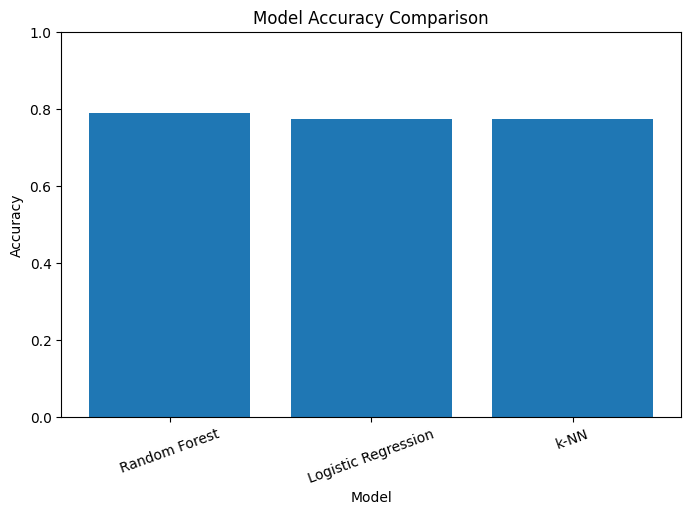

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 9. Document Embeddings with Doc2Vec

In addition to TF-IDF, this section learns dense document embeddings from the full artwork metadata. Each artwork is treated as one document, and the learned vectors are later visualized with t-SNE and used as features for classification models.

In [ ]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.6 MB/s eta 0:00:00


In [ ]:
train_texts = X_train_text.copy()
test_texts = X_test_text.copy()

print(train_texts.iloc[0])

title=Head of an Old Man with Beard artist=Edvard Munch
Norwegian, 1863-1944 culture=Norway medium=Color woodcut on paper dimensions=Image: 46 × 32.5 cm (18 1/8 × 12 13/16 in.); Plate: 53.5 × 40 cm (21 1/8 × 15 3/4 in.); Sheet: 66.4 × 49.4 cm (26 3/16 × 19 1/2 in.) classification=woodcut department=Prints and Drawings objectName=Print source=Art Institute of Chicago


In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import numpy as np

train_tagged = [
    TaggedDocument(words=text.split(), tags=[str(i)])
    for i, text in enumerate(train_texts)
]

doc2vec_model = Doc2Vec(
    vector_size=200,
    window=8,
    min_count=1,
    workers=4,
    epochs=80,
    dm=1,
    negative=10,
    seed=42
)

doc2vec_model.build_vocab(train_tagged)
doc2vec_model.train(
    train_tagged,
    total_examples=doc2vec_model.corpus_count,
    epochs=doc2vec_model.epochs
)

X_train_doc2vec = np.array([
    doc2vec_model.infer_vector(text.split(), epochs=30)
    for text in train_texts
])

X_test_doc2vec = np.array([
    doc2vec_model.infer_vector(text.split(), epochs=30)
    for text in test_texts
])

## 10. Visualize Embeddings with t-SNE

This section reduces the high-dimensional Doc2Vec embeddings into two dimensions so they can be plotted. If the embeddings capture meaningful patterns, artworks from similar centuries may appear in nearby clusters.

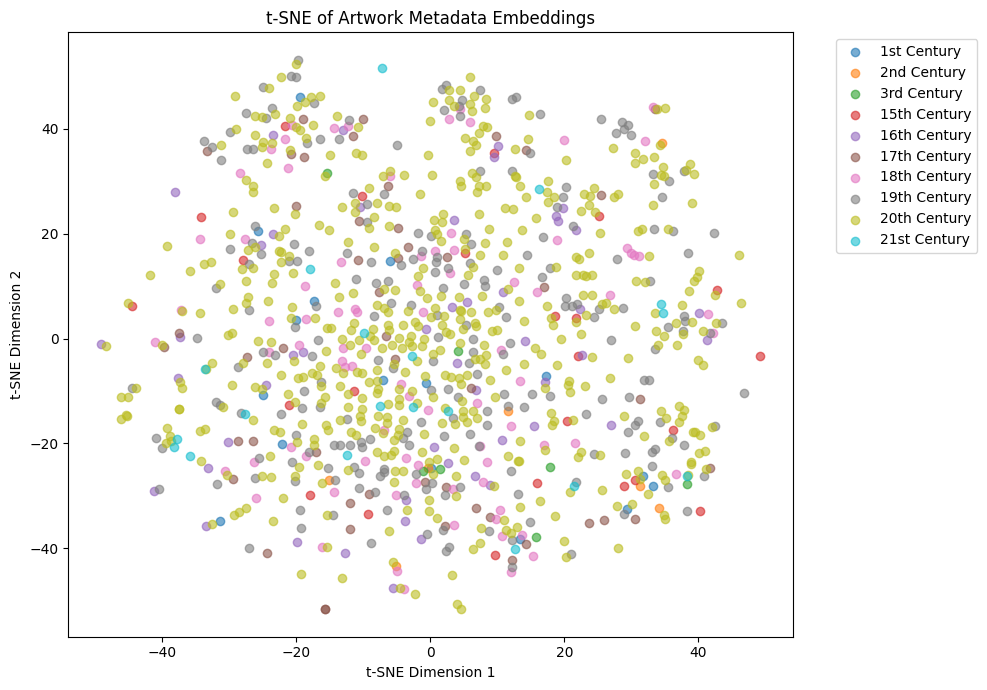

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import re

sample_size = min(1000, len(X_train_doc2vec))
X_sample = X_train_doc2vec[:sample_size]
y_sample = y_train[:sample_size]

tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate=200,
    init="pca",
    random_state=42,
    max_iter=2000
)

X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "century": y_sample
})

plt.figure(figsize=(10, 7))
for century in sorted(tsne_df["century"].unique(), key=lambda x: int(re.search(r"\d+", x).group())):
    subset = tsne_df[tsne_df["century"] == century]
    plt.scatter(subset["x"], subset["y"], label=century, alpha=0.6)

plt.title("t-SNE of Artwork Metadata Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Train Models on Doc2Vec Embeddings

This section trains machine learning models on the learned document embeddings instead of TF-IDF features.

In [ ]:
embedding_models = {
    "Logistic Regression (Doc2Vec)": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "k-NN (Doc2Vec)": KNeighborsClassifier(n_neighbors=21, weights="distance"),
    "Random Forest (Doc2Vec)": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
}

embedding_results = []
embedding_predictions = {}

for name, model in embedding_models.items():
    model.fit(X_train_doc2vec, y_train)
    preds = model.predict(X_test_doc2vec)
    acc = accuracy_score(y_test, preds)

    embedding_results.append({"Model": name, "Accuracy": acc})
    embedding_predictions[name] = preds

    print("=" * 60)
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds, zero_division=0))

embedding_results_df = pd.DataFrame(embedding_results).sort_values(by="Accuracy", ascending=False)
embedding_results_df

Logistic Regression (Doc2Vec)
Accuracy: 0.1433370660694289
              precision    recall  f1-score   support

15th Century       0.04      0.16      0.07        37
16th Century       0.21      0.34      0.26        68
17th Century       0.18      0.15      0.16        95
18th Century       0.22      0.16      0.19       166
19th Century       0.39      0.16      0.23       412
 1st Century       0.07      0.48      0.13        33
20th Century       0.80      0.09      0.17       899
21st Century       0.09      0.19      0.12        37
 2nd Century       0.02      0.24      0.03        21
 3rd Century       0.01      0.33      0.02        18

    accuracy                           0.14      1786
   macro avg       0.21      0.23      0.14      1786
weighted avg       0.54      0.14      0.18      1786

k-NN (Doc2Vec)
Accuracy: 0.4708846584546473
              precision    recall  f1-score   support

15th Century       0.00      0.00      0.00        37
16th Century       0.00      

,Model,Accuracy
2,Random Forest (Doc2Vec),0.503359
1,k-NN (Doc2Vec),0.470885
0,Logistic Regression (Doc2Vec),0.143337


## 12. Compare TF-IDF and Doc2Vec Results

                           Model  Accuracy
0                  Random Forest  0.788914
1            Logistic Regression  0.775476
2                           k-NN  0.774356
3        Random Forest (Doc2Vec)  0.503359
4                 k-NN (Doc2Vec)  0.470885
5  Logistic Regression (Doc2Vec)  0.143337


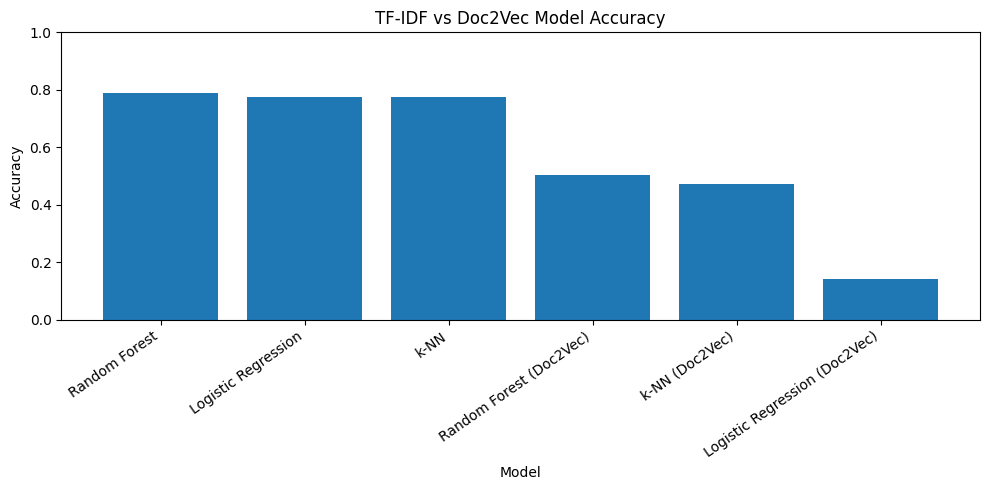

In [ ]:
all_results_df = pd.concat([results_df, embedding_results_df], ignore_index=True)
all_results_df = all_results_df.sort_values(by="Accuracy", ascending=False)

print(all_results_df)

plt.figure(figsize=(10, 5))
plt.bar(all_results_df["Model"], all_results_df["Accuracy"])
plt.title("TF-IDF vs Doc2Vec Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

##Confusion Matrix

Shows which centuries the best model confuses most often. Adjacent centuries (e.g. 19th vs 20th)
are expected to overlap more than distant ones
a pattern worth discussing in your report.

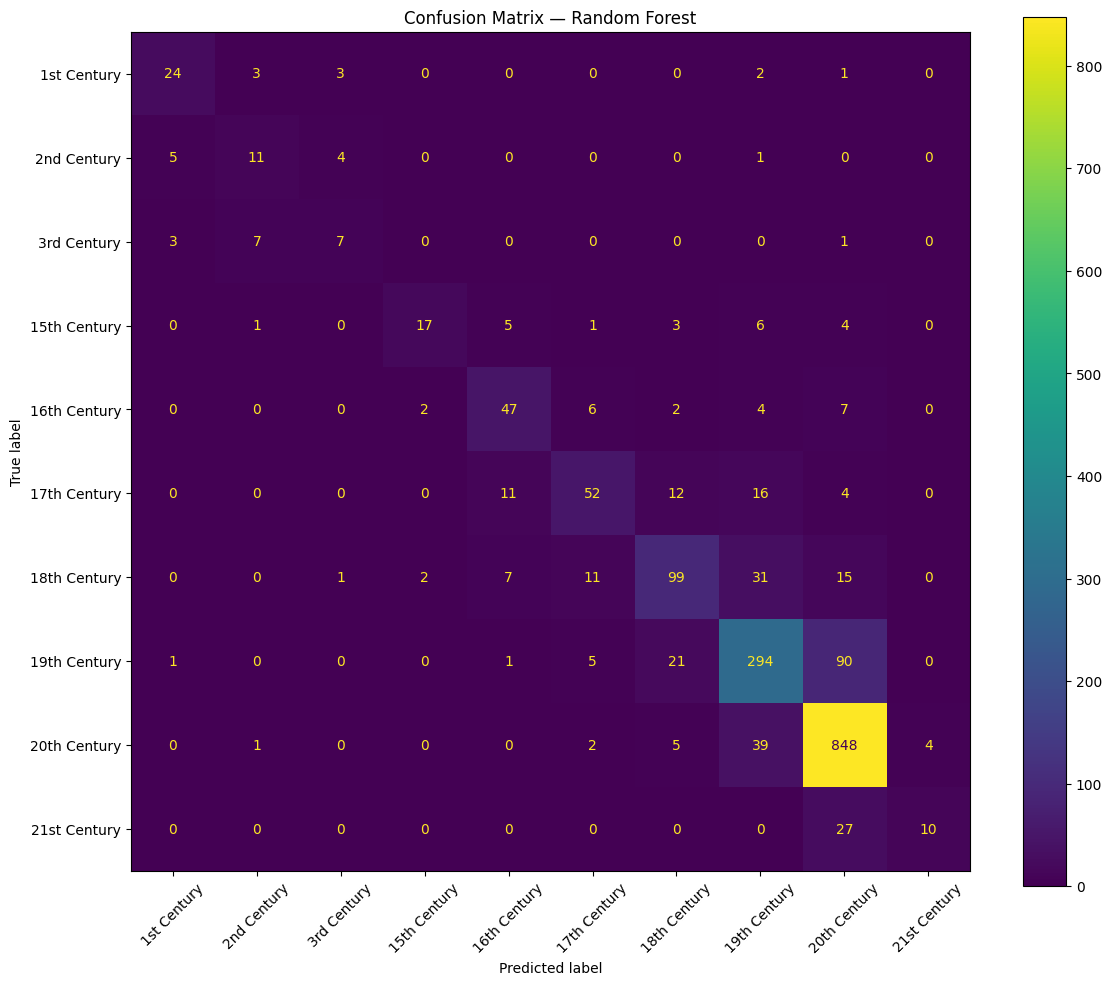

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_preds = predictions[best_model_name]

sorted_labels = sorted(y_test.unique(), key=lambda x: int(re.search(r"\d+", x).group()))

cm = confusion_matrix(y_test, best_preds, labels=sorted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted_labels)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

##Feature Importance Analysis

Random Forest Top Features by Importance
Random Forest provides a direct feature imprtance score for each token.

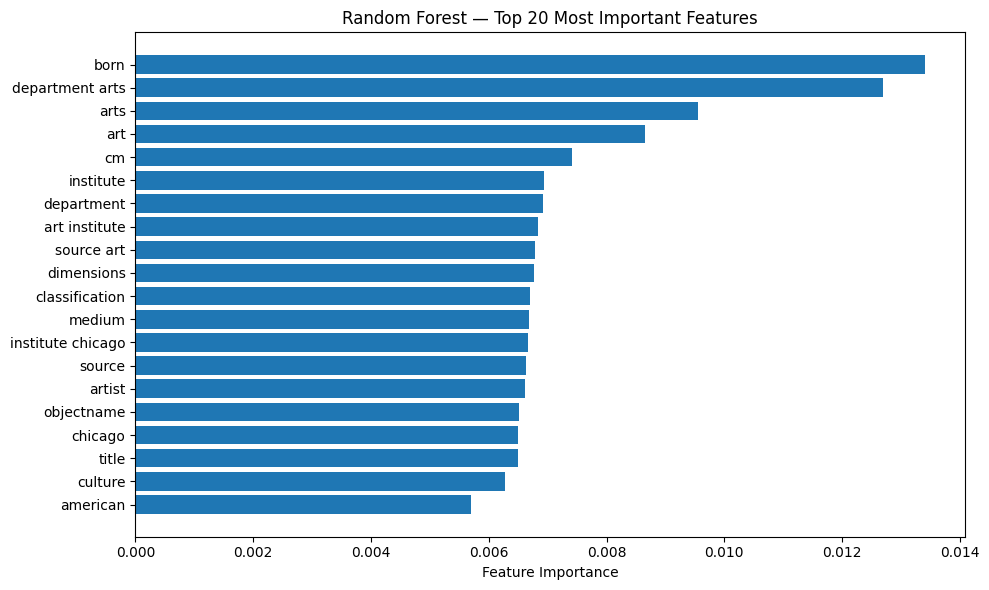

Top 20 features (Random Forest):
          feature  importance
             born    0.013411
  department arts    0.012688
             arts    0.009549
              art    0.008660
               cm    0.007410
        institute    0.006943
       department    0.006920
    art institute    0.006842
       source art    0.006782
       dimensions    0.006763
   classification    0.006693
           medium    0.006686
institute chicago    0.006670
           source    0.006635
           artist    0.006623
       objectname    0.006511
          chicago    0.006490
            title    0.006489
          culture    0.006282
         american    0.005702


In [ ]:
rf_pipeline = models["Random Forest"]
rf_vectorizer = rf_pipeline.named_steps["tfidf"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["feature"][::-1], rf_importance_df["importance"][::-1])
plt.title("Random Forest — Top 20 Most Important Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("Top 20 features (Random Forest):")
print(rf_importance_df.to_string(index=False))

### Logistic Regression
Top Features Per Century :
Logistic Regression coefficients show which tokens most strongly push toward each century class.

In [ ]:
lr_pipeline = models["Logistic Regression"]
lr_vectorizer = lr_pipeline.named_steps["tfidf"]
lr_model = lr_pipeline.named_steps["model"]

lr_feature_names = lr_vectorizer.get_feature_names_out()
classes = lr_model.classes_
top_n = 10

print("Top features per century (Logistic Regression):")
for i, century_label in enumerate(classes):
    coefs = lr_model.coef_[i]
    top_indices = np.argsort(coefs)[-top_n:][::-1]
    top_features = [(lr_feature_names[j], round(coefs[j], 4)) for j in top_indices]
    print(f"\n{century_label}:")
    for feat, score in top_features:
        print(f"  {feat}: {score}")

Top features per century (Logistic Regression):

15th Century:
  tempera: 3.3829
  panel: 3.3281
  medium tempera: 2.9319
  tempera panel: 2.3723
  netherlandish: 2.2341
  master: 2.1883
  thailand: 1.9596
  asia: 1.8568
  di: 1.8083
  southern: 1.7854

16th Century:
  italian: 3.1619
  italy: 2.4374
  oil panel: 2.215
  cannon: 2.085
  jacopo: 2.0562
  black ivory: 2.012
  italy medium: 1.9834
  urbino: 1.9581
  velvet: 1.8838
  woodcut: 1.8676

17th Century:
  dutch: 3.7709
  culture holland: 2.3085
  holland medium: 2.3085
  holland: 2.3001
  etching: 2.1107
  delft: 2.0853
  flemish: 2.0785
  silk: 1.97
  1664 culture: 1.763
  1610: 1.7061

18th Century:
  jean: 2.1028
  england: 2.0314
  porcelain: 1.99
  18th: 1.9534
  france: 1.9183
  woodblock print: 1.7163
  canvas: 1.6574
  woodblock: 1.6462
  1733: 1.5009
  18th century: 1.4855

19th Century:
  france medium: 2.3896
  culture france: 2.3896
  french: 2.1589
  france: 2.07
  english: 1.7276
  albumen: 1.5256
  americas: 1.506